# Exercise 1

We first load a dataset and examine its dimensions.

In [10]:
# If you are running this on Google Colab, uncomment and run the following lines; otherwise ignore this cell
# from google.colab import drive
# drive.mount('/content/drive')

In [11]:
import math
import numpy as np

xy_data = np.load('Ex1_polyreg_data.npy')
# If running on Google Colab change path to '/content/drive/MyDrive/IB-Data-Science/Exercises/Ex1_polyreg_data.npy'

np.shape(xy_data)
print(xy_data)

[[ 0.00000000e+00 -2.54683883e+00]
 [ 1.00000000e-01 -1.93121366e+00]
 [ 2.00000000e-01 -8.25007629e-02]
 [ 3.00000000e-01  1.38292514e-01]
 [ 4.00000000e-01 -2.70644283e+00]
 [ 5.00000000e-01 -3.41147806e+00]
 [ 6.00000000e-01  2.35498628e-01]
 [ 7.00000000e-01 -2.87783453e-01]
 [ 8.00000000e-01 -9.49774826e-01]
 [ 9.00000000e-01  1.71649208e-01]
 [ 1.00000000e+00  1.06093139e-01]
 [ 1.10000000e+00 -6.29462307e-02]
 [ 1.20000000e+00  3.18570501e+00]
 [ 1.30000000e+00  3.15716440e+00]
 [ 1.40000000e+00  1.37893464e+00]
 [ 1.50000000e+00  2.50223499e+00]
 [ 1.60000000e+00 -4.12083872e-02]
 [ 1.70000000e+00 -2.58123192e-01]
 [ 1.80000000e+00  3.97416190e+00]
 [ 1.90000000e+00  3.62036166e+00]
 [ 2.00000000e+00  3.21917341e+00]
 [ 2.10000000e+00  1.41900746e+00]
 [ 2.20000000e+00  3.24534798e-01]
 [ 2.30000000e+00  2.69365546e+00]
 [ 2.40000000e+00  1.73604945e-02]
 [ 2.50000000e+00  2.41259309e+00]
 [ 2.60000000e+00  3.95776835e+00]
 [ 2.70000000e+00  1.81406394e+00]
 [ 2.80000000e+00  4

The matrix `xy_data` contains $70$ rows, each a data point of the form $(x_i,y_i)$ for $i=1, \ldots, 70$.

### 1a) Plot the data in a scatterplot.

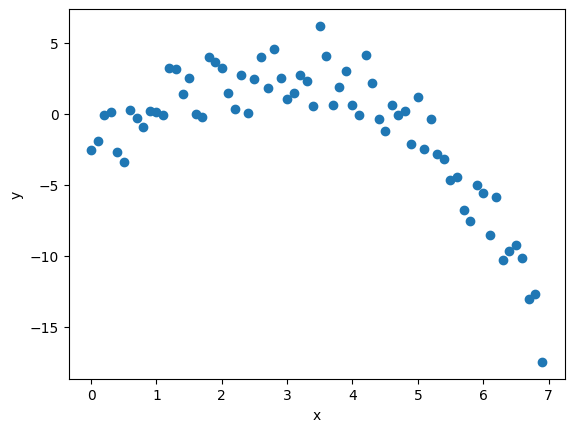

In [12]:
import matplotlib.pyplot as plt
plt.scatter(xy_data[:, 0], xy_data[:, 1]) #take all rows of column 0 for x and all rows of column 1 for y
plt.xlabel('x')
plt.ylabel('y')
plt.show()



### 1b) Write a function `polyreg` to fit a polynomial of a given order to a dataset. 
The inputs to the function are a data matrix of dimension $N \times 2$,  and $k \geq 0$, the order of the polynomial.   The function should compute the coefficients of the polynomial $\beta_0 + \beta_1 x +  \ldots  +\beta_k x^{k}$ via least squares regression, and should return the coefficient vector, the fit, and the vector of residuals. 

If specified the degree $k$ is greater than or equal to $N$, then the function must fit an order $(N-1)$ polynomial and set the remaining coefficients to zero.

**NOTE**: You are *not* allowed to use the built-in function `np.polyfit`.

In [13]:
def polyreg(data_matrix, k):
    # N = Number of data points (rows in the data mat)
    N = np.shape(data_matrix)[0]

    # Extract x and y columns from the data mat
    x = data_matrix[:, 0]
    y = data_matrix[:, 1]

    # As instructed, If k is too large (>=N), we only fit up to degree N - 1, and set all remaining coeff to 0
    if k >= N:
        degree = N - 1
    else:
        degree = k

    # Create the design matrix X with zeros initially
    # It has N rows and (degree + 1) columns
    X = np.zeros((N, degree + 1))

    # Fill the design matrix column by column
    for i in range(degree + 1):
        X[:, i] = x ** i

    # Calculate the least squares coefficients
    # Formula: beta = (X^T * X)^(-1) * X^T * y
    X_transpose = np.transpose(X)
    X_transpose_X = np.matmul(X_transpose, X)
    X_transpose_X_inv = np.linalg.inv(X_transpose_X)
    X_transpose_y = np.matmul(X_transpose, y)

    # Coefficients for the effective degree
    beta_effective = np.matmul(X_transpose_X_inv, X_transpose_y)

    # Create the full beta array of size (k + 1) filled with zeros
    beta = np.zeros(k + 1)

    # Copy the calculated coefficients into the final beta array
    for i in range(degree + 1):
        beta[i] = beta_effective[i]

    # Calculate the fitted values
    # fit = X * beta_effective
    fit = np.matmul(X, beta_effective)

    # Calculate the residuals (actual y - fitted y)
    residuals = y - fit

    return beta, fit, residuals


Use the tests below to check the outputs of the function you have written:

In [14]:
# Some tests to make sure your function is working correctly

xcol = np.arange(-1, 1.05, 0.1)
ycol = 2 - 7*xcol + 3*(xcol**2)  # We are generating data accoridng to y = 2 - 7x + 3x^2
test_matrix = np.transpose(np.vstack((xcol,ycol)))
test_matrix.shape

beta_test = polyreg(test_matrix, k=2)[0] 
assert((np.round(beta_test[0], 3) == 2) and (np.round(beta_test[1], 3) == -7) and (np.round(beta_test[2], 3) == 3))  
# We want to check that using the function with k=2 recovers the coefficients exactly

# Now check the zeroth order fit, i.e., the function gives the correct output with k=0
beta_test = polyreg(test_matrix, k=0)[0]
res_test = polyreg(test_matrix, k=0)[2] #the last output of the function gives the vector of residuals

assert(np.round(beta_test, 3) == 3.1)
assert(np.round(np.linalg.norm(res_test), 3) == 19.937)

### 1c) Use `polyreg` to fit polynomial models for the data in `xy_data` for $k=2,3,4$:

- Plot the fits for the three cases on the same plot together with the scatterplot of the data. The plots should be labelled and a legend included. 
- Compute and print the SSE and $R^2$ coefficient for each of the three cases.
- Which of the three models you would choose? Briefly justify your choice.

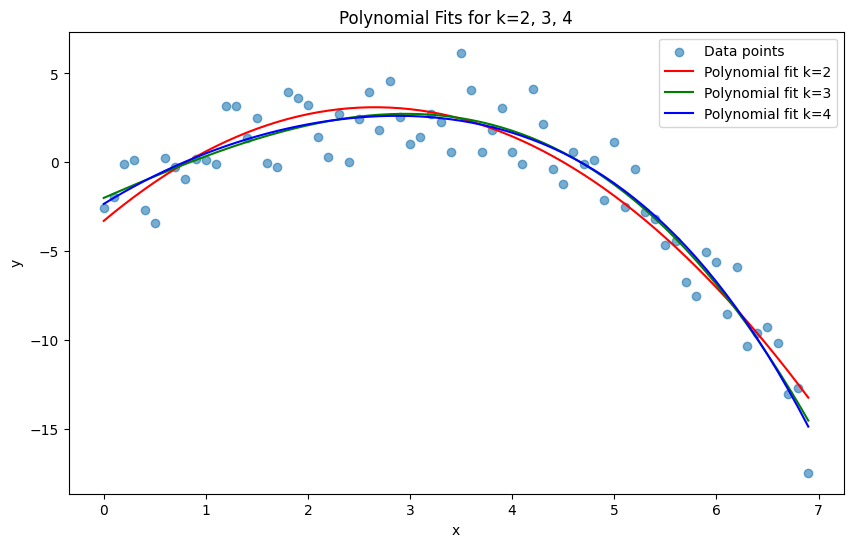

For k=2: SSE = 172.181, R^2 = 0.888
For k=3: SSE = 152.406, R^2 = 0.901
For k=4: SSE = 151.228, R^2 = 0.901


In [16]:
# Fit polynomials for k=2, 3, 4
beta2, fit2, res2 = polyreg(xy_data, 2)
beta3, fit3, res3 = polyreg(xy_data, 3)
beta4, fit4, res4 = polyreg(xy_data, 4)

# sort so the line plots are plotted in order of x vals
sort_indices = np.argsort(xy_data[:, 0])
x_sorted = xy_data[sort_indices, 0]
fit2_sorted = fit2[sort_indices]
fit3_sorted = fit3[sort_indices]
fit4_sorted = fit4[sort_indices]

# Plot scatterplot and fits
plt.figure(figsize=(10, 6))
plt.scatter(xy_data[:, 0], xy_data[:, 1], label='Data points', alpha=0.6)
plt.plot(x_sorted, fit2_sorted, label='Polynomial fit k=2', color='red')
plt.plot(x_sorted, fit3_sorted, label='Polynomial fit k=3', color='green')
plt.plot(x_sorted, fit4_sorted, label='Polynomial fit k=4', color='blue')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Polynomial Fits for k=2, 3, 4')
plt.legend()
plt.show()

# For each model, Compute SSE and R^2
y = xy_data[:, 1]
y_mean = np.mean(y)
SST = np.sum((y - y_mean)**2)

for k, res in [(2, res2), (3, res3), (4, res4)]:
    SSE = np.sum(res**2)
    R2 = 1 - SSE / SST
    print(f'For k={k}: SSE = {SSE:.3f}, R^2 = {R2:.3f}')


 #### State which model you choose and briefly justify your choice.
 
I choose the model with k=3 as it fits the provided data better (higher R^2, lower SSE) compared to k=2. k=4 offers little  improvement in R^2 and can risk overfitting.


### 1d)  For the model you have chosen in the previous part (either $k=2/3/4)$:

- Plot the residuals in a scatter plot. 
- Plot a histogram of the residuals along with a Gaussian pdf with zero mean and the same standard deviation as the residuals.

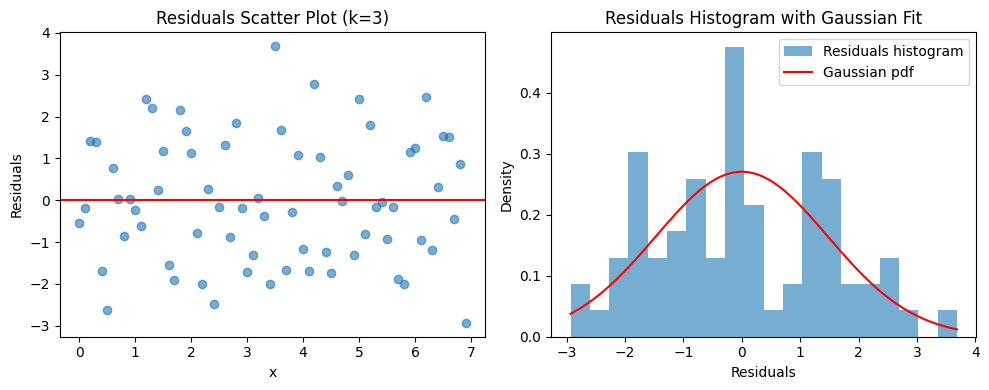

In [19]:
# pick model k=3

# Plot residuals in scatter plot
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(xy_data[:, 0], res3, alpha=0.6)
plt.xlabel('x')
plt.ylabel('Residuals')
plt.title('Residuals Scatter Plot (k=3)')
plt.axhline(0, color='red')

# Plot histogram of residuals with Gaussian pdf
plt.subplot(1, 2, 2)
plt.hist(res3, bins=20, density=True, alpha=0.6, label='Residuals histogram')

# Gaussian pdf with zero mean and same std as the residuals
import scipy.stats as stats
std_res = np.std(res3)
x_gauss = np.linspace(min(res3), max(res3), 100)
plt.plot(x_gauss, stats.norm.pdf(x_gauss, 0, std_res), label='Gaussian pdf', color='red')
plt.xlabel('Residuals')
plt.ylabel('Density')
plt.title('Residuals Histogram with Gaussian Fit')
plt.legend()

plt.tight_layout()
plt.show()
